# Détection de raies par résidu de diffusion — Gabor, Radon, Hough

Ce notebook rejoue, étape par étape, le pipeline déjà implémenté dans
`src/` et `scripts/` pour la dernière étape du challenge (voir
`diffusion_anomaly.pdf`, section 5) : transformer le résidu de purification
d'un patch en une décision `horizontal` / `other`, **sans entraînement
supervisé**

In [2]:
import os
import sys
import json

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = os.path.abspath("..")
sys.path.append(os.path.join(ROOT, "src"))

DATASET_DIR = os.path.join(ROOT, "dataset")
TEST_DIR = os.path.join(DATASET_DIR, "test")
MODELS_DIR = os.path.join(ROOT, "models")
OUT_DIR = os.path.join(ROOT, "outputs")

with open(os.path.join(DATASET_DIR, "annotations.json")) as f:
    annotations = json.load(f)

n_test = len([f for f in os.listdir(TEST_DIR) if f.endswith(".npy")])
horizontal = np.array([a["horizontal"] for a in annotations.values()], dtype=bool)
other = np.array([a["other"] for a in annotations.values()], dtype=bool)
print(f"Annotated patches      : {len(annotations)} / {n_test}")
print(f"  No line              : {np.sum(~horizontal & ~other)}")
print(f"  Horizontal only      : {np.sum(horizontal & ~other)}")
print(f"  Other only           : {np.sum(~horizontal & other)}")
print(f"  Horizontal and other : {np.sum(horizontal & other)}")


Annotated patches      : 502 / 2863
  No line              : 364
  Horizontal only      : 57
  Other only           : 68
  Horizontal and other : 13


In [3]:
ANGLE_STEP = 5.0
ANGLES = np.arange(0, 180, ANGLE_STEP)
H_TOL = 10.0  # tolérance (°) autour de l'horizontale (0° / 180°)
V_TOL = 10.0  # tolérance (°) autour de la verticale (90°), bande exclue

# Seuils de décision [horizontal, other] par détecteur, calibrés sur les
# patches non annotés
THRESHOLDS = {
    "radon": [1.4465, 1.0651],
    "hough": [0.6042, 0.4400],
    "gabor": [0.4042, 0.4393],
}

print(f"[INFO] ANGLES  : pas={ANGLE_STEP:g}°, {len(ANGLES)} orientations testées")
print(f"[INFO] H_TOL={H_TOL:g}°  V_TOL={V_TOL:g}°")


[INFO] ANGLES  : pas=5°, 36 orientations testées
[INFO] H_TOL=10°  V_TOL=10°


In [27]:
GABOR_WAVELENGTH = 6.0     # période de la sinusoïde, largeur de ligne de 3 pixels ici
GABOR_SIGMA_ALONG = 10.0   # longueur de l'enveloppe le long de la raie, permet de
                           # distinguer le bruit de la raie
GABOR_SIGMA_ACROSS = 2.0   # épaisseur de l'enveloppe perpendiculairement à la raie
GABOR_SIZE = 25            # taille du noyau (impair)

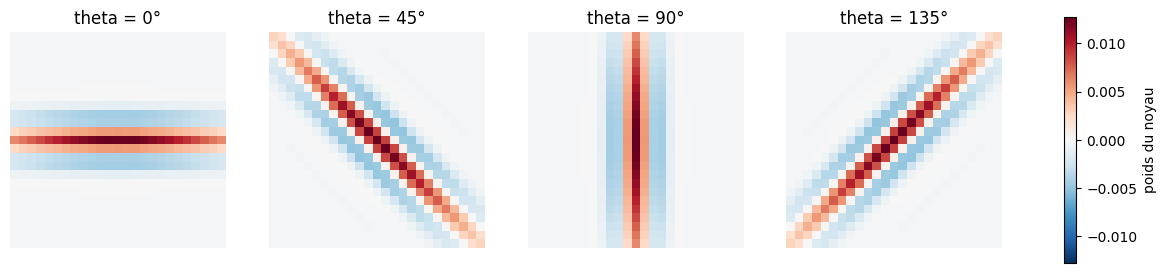

In [28]:
def gabor_kernel(
    theta_deg: float, wavelength: float = GABOR_WAVELENGTH,
    sigma_along: float = GABOR_SIGMA_ALONG,
    sigma_across: float = GABOR_SIGMA_ACROSS, size: int = GABOR_SIZE,
) -> np.ndarray:
    half = size // 2
    r, c = np.mgrid[-half : half + 1, -half : half + 1].astype(np.float64)
    th = np.deg2rad(theta_deg)

    # (u, v) : coordonnées tournées, u le long de la ligne, v perpendiculaire
    u = c * np.cos(th) + r * np.sin(th)
    v = -c * np.sin(th) + r * np.cos(th)

    # enveloppe gaussienne anisotrope : large selon u, étroite selon v
    envelope = np.exp(-(u**2 / (2 * sigma_along**2) + v**2 / (2 * sigma_across**2)))
    # modulation cosinus le long de v -> répond à une bande claire de largeur ~wavelength
    carrier = np.cos(2 * np.pi * v / wavelength)

    g = envelope * carrier
    g -= g.mean()               # moyenne nulle : pas de réponse sur fond plat
    return g / np.abs(g).sum()  # normalisation L1 : réponses comparables entre theta


def gabor_profile(
    e: np.ndarray, angles: np.ndarray = ANGLES, **kernel_kwargs
) -> np.ndarray:
    """
    Banc de filtres de Gabor : pour chaque orientation, max de la réponse
    (convolution) sur le patch. Le padding en miroir évite les faux bords
    créés par les bords du patch.
    """
    kernels = np.stack([gabor_kernel(th, **kernel_kwargs) for th in angles])
    k = torch.from_numpy(kernels[:, None]).float()
    pad = k.shape[-1] // 2
    x = torch.from_numpy(e[None, None].astype(np.float32))
    x = F.pad(x, (pad, pad, pad, pad), mode="reflect")
    resp = F.conv2d(x, k)[0]
    return resp.amax(dim=(1, 2)).numpy()


# Aperçu du noyau pour quelques orientations
angles_preview = [0, 45, 90, 135]
fig, axes = plt.subplots(1, len(angles_preview), figsize=(4 * len(angles_preview), 4))
for ax, theta in zip(axes, angles_preview):
    k = gabor_kernel(theta)
    im = ax.imshow(k, cmap="RdBu_r", vmin=-np.abs(k).max(), vmax=np.abs(k).max())
    ax.set_title(f"theta = {theta}°")
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8, label="poids du noyau")
plt.show()


In [5]:
# Paramètre de Radon (et de Hough, qui réutilise _accumulate), choisi a priori :
# il n'est pas réglé sur les annotations.
MIN_LEN = 24  # longueur minimale (pixels) d'une droite gardée ; les patches font 48x48


def _line_coordinates(shape: tuple[int, int], theta_deg: float) -> np.ndarray:
    """
    Distance signée rho de chaque pixel à la droite passant par le centre du
    patch avec l'orientation theta. Les pixels d'une même droite partagent le
    même rho.
    """
    H, W = shape
    r, c = np.mgrid[0:H, 0:W].astype(np.float64)
    r -= (H - 1) / 2
    c -= (W - 1) / 2
    th = np.deg2rad(theta_deg)
    return -c * np.sin(th) + r * np.cos(th)


def _accumulate(
    e: np.ndarray, theta_deg: float, min_len: int
) -> tuple[np.ndarray, np.ndarray]:
    """
    Somme et nombre de pixels de e le long de chaque droite parallèle
    d'orientation theta, en ne gardant que les droites d'au moins `min_len`
    pixels.
    """
    rho = _line_coordinates(e.shape, theta_deg)
    idx = np.round(rho - rho.min()).astype(int).ravel()
    n = idx.max() + 1
    total = np.bincount(idx, weights=e.ravel(), minlength=n)
    count = np.bincount(idx, minlength=n)
    keep = count >= min_len
    return total[keep], count[keep]


def radon_profile(
    e: np.ndarray, angles: np.ndarray = ANGLES, min_len: int = MIN_LEN
) -> np.ndarray:
    """
    Transformée de Radon : moyenne de e le long de chaque droite, puis max
    sur les droites. La moyenne (et non la somme) rend les droites de
    longueurs différentes comparables ; `min_len` élimine les petites
    droites de coin, trop bruitées.
    """
    prof = []
    for th in angles:
        total, count = _accumulate(e, th, min_len)
        prof.append((total / count).max())
    return np.array(prof)


In [6]:
# Paramètre de Hough, choisi a priori (min_len : voir la cellule de Radon).
HOUGH_QUANTILE = 0.9  # on garde les 10 % de pixels les plus forts du patch


def hough_profile(
    e: np.ndarray,
    angles: np.ndarray = ANGLES,
    quantile: float = HOUGH_QUANTILE,
    min_len: int = MIN_LEN,
) -> np.ndarray:
    """
    Transformée de Hough : on binarise e en gardant les pixels au-dessus
    d'un quantile (carte binaire), chaque pixel "on" vote pour les droites
    qui passent par lui, et on retient la fraction de vote maximale sur les
    droites (fraction de pixels "on" parmi les pixels de la droite).
    """
    binary = (e >= np.quantile(e, quantile)).astype(np.float64)
    prof = []
    for th in angles:
        votes, count = _accumulate(binary, th, min_len)
        prof.append((votes / count).max())
    return np.array(prof)


In [7]:
def scores_from_profile(
    profile: np.ndarray,
    angles: np.ndarray = ANGLES,
    h_tol: float = H_TOL,
    v_tol: float = V_TOL,
) -> tuple[float, float]:
    """
    Score horizontal (theta à moins de h_tol de 0° ou 180°) et score other
    (toutes les autres orientations, sauf la bande verticale exclue autour
    de 90° ± v_tol : une raie verticale n'est ni horizontal ni other).
    """
    dist_h = np.minimum(angles, 180 - angles)
    horizontal_band = dist_h <= h_tol
    vertical_band = np.abs(angles - 90) <= v_tol
    other_band = ~horizontal_band & ~vertical_band
    return float(profile[horizontal_band].max()), float(profile[other_band].max())


def scores_from_profiles(
    profiles: np.ndarray,
    angles: np.ndarray = ANGLES,
    h_tol: float = H_TOL,
    v_tol: float = V_TOL,
) -> np.ndarray:
    """
    Tableau (N, 2) des scores horizontal et other de N profils.
    """
    return np.array([scores_from_profile(p, angles, h_tol, v_tol) for p in profiles])


## Comment on passe du profil aux deux scores

Chaque détecteur (Gabor, Radon, Hough) renvoie, pour un patch, un **profil d'orientation** : une valeur par angle `theta` (36 angles, de 0° à 175°), d'autant plus grande qu'une raie claire est présente dans cette direction.

On résume ce profil par deux nombres, un par label, en prenant le **maximum du profil sur une bande d'angles** :

| score | bande d'angles utilisée |
|---|---|
| `horizontal` | `theta` à moins de `H_TOL` (10°) de 0° ou de 180° |
| `other` | tous les autres angles, **sauf** la bande verticale `90° ± V_TOL` |

- La bande verticale est exclue des deux scores : une raie verticale n'est ni `horizontal` ni `other` dans les annotations, elle est donc traitée comme « pas de raie ».
- Prendre le max (et non la moyenne) revient à demander : « existe-t-il *une* direction dans cette bande où une raie ressort ? »
- Les deux bandes ne contiennent pas le même nombre d'angles (5 contre ~26 avec `H_TOL=V_TOL=10`). Le max sur du bruit pur est donc plus grand pour `other` que pour `horizontal` : **les deux scores ne sont pas comparables entre eux**, d'où deux seuils distincts (voir plus bas).

Un score est ensuite transformé en décision par un simple seuil : `score > seuil` ⇒ le label est prédit.


In [8]:
from inference import load_diffusion_model
from purification import residual_maps


In [9]:
EXAMPLES = {
    "horizontal": ["patch_9107_22.npy", "patch_9448_21.npy"],
    "other": ["patch_9150_13.npy", "patch_9241_11.npy"],
    "both": ["patch_9351_13.npy", "patch_9350_10.npy"],
    "none": ["patch_978_21.npy", "patch_981_21.npy"],
}
names = [(cat, f) for cat, files in EXAMPLES.items() for f in files]

T_START, DDIM_STEPS, SEED = 600, 6, 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model, schedule = load_diffusion_model(os.path.join(MODELS_DIR, "unet32.pt"), DEVICE)

patches = np.stack([
    np.load(os.path.join(TEST_DIR, f)).astype(np.float32).squeeze() for _, f in names
])
residuals = residual_maps(patches, model, schedule, T_START, DDIM_STEPS, SEED, DEVICE)

print(f"[INFO] résidus: {residuals.shape}, quelques exemples :")
for (cat, f), e in list(zip(names, residuals))[:3]:
    print(f"  {cat:10s} {f:20s} mean={e.mean():.4f}  max={e.max():.4f}")


[INFO] résidus: (8, 48, 48), quelques exemples :
  horizontal patch_9107_22.npy    mean=0.4805  max=6.3726
  horizontal patch_9448_21.npy    mean=0.5107  max=4.0564
  other      patch_9150_13.npy    mean=0.4943  max=5.8193


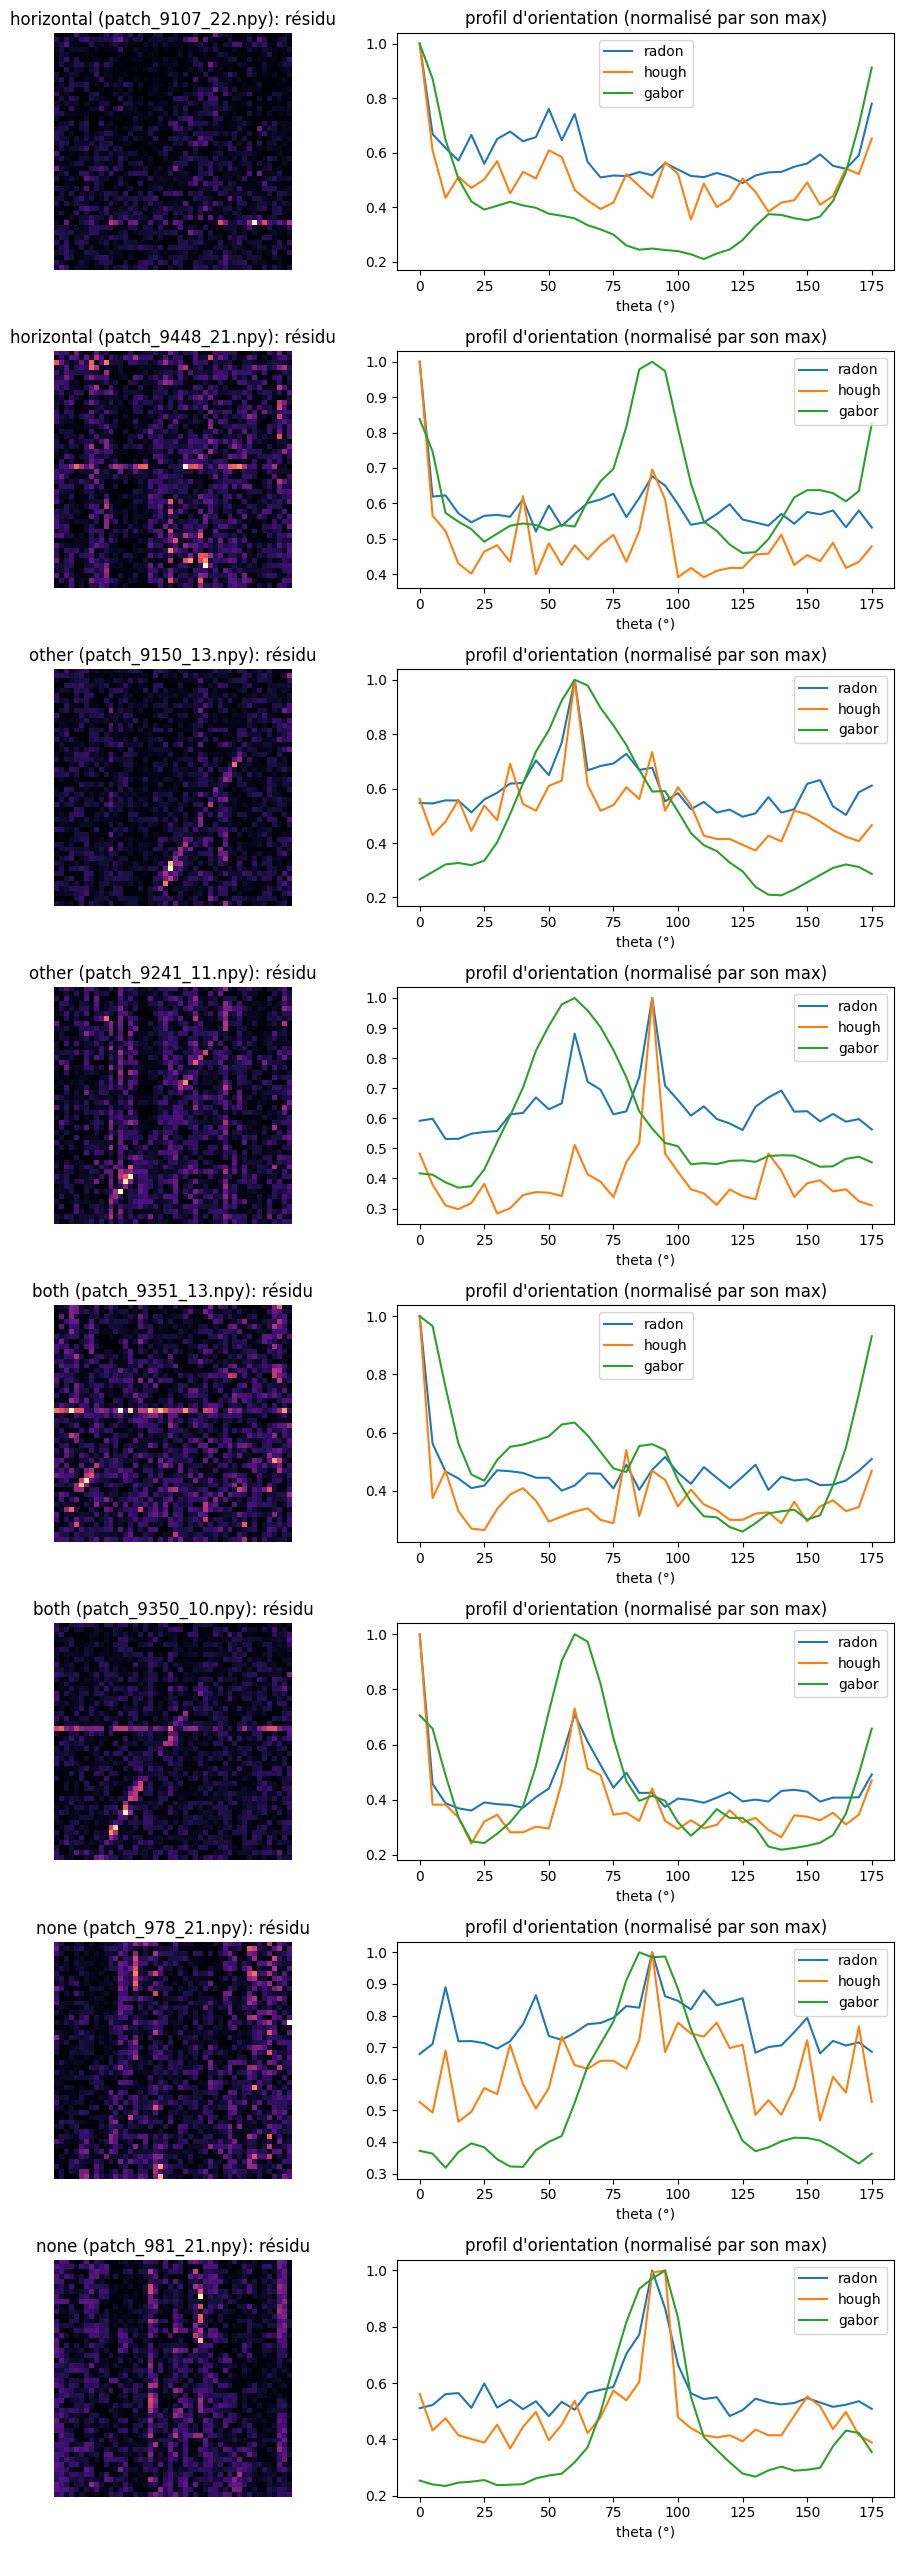

In [10]:
detectors = {"radon": radon_profile, "hough": hough_profile, "gabor": gabor_profile}

fig, axes = plt.subplots(len(names), 2, figsize=(10, 3.2 * len(names)))
for row, ((cat, f), e) in enumerate(zip(names, residuals)):
    axes[row, 0].imshow(e, origin="lower", cmap="magma")
    axes[row, 0].set_title(f"{cat} ({f}): résidu")
    axes[row, 0].axis("off")

    for det_name, detector in detectors.items():
        prof = detector(e)
        axes[row, 1].plot(ANGLES, prof / prof.max(), label=det_name)
    axes[row, 1].set_xlabel("theta (°)")
    axes[row, 1].set_title("profil d'orientation (normalisé par son max)")
    axes[row, 1].legend()
plt.tight_layout()
plt.show()


In [11]:
annotated_files = list(annotations.keys())
annotated_raw = np.stack([
    np.load(os.path.join(TEST_DIR, f)).astype(np.float32).squeeze() for f in annotated_files
])
annotated_residuals = residual_maps(
    annotated_raw, model, schedule, T_START, DDIM_STEPS, SEED, DEVICE
)

print(f"[INFO] résidus calculés pour {len(annotated_files)} patches annotés, quelques exemples :")
for f, e in list(zip(annotated_files, annotated_residuals))[:3]:
    print(f"  {f:20s} mean={e.mean():.4f}  max={e.max():.4f}")


[INFO] résidus calculés pour 502 patches annotés, quelques exemples :
  patch_9448_21.npy    mean=0.5065  max=4.4539
  patch_978_21.npy     mean=0.4252  max=3.2900
  patch_981_21.npy     mean=0.3656  max=3.5788


In [12]:
# scores_from_profile utilise H_TOL/V_TOL par défaut (cf. cellule de
# paramètres en haut du notebook, cohérent avec outputs/run_config.json) :
# theta proche de 0°/180° -> score "horizontal" ; theta ailleurs SAUF la bande
# +-V_TOL autour de 90° -> score "other". Une raie verticale n'est donc ni
# horizontal ni other : elle est exclue des deux scores, traitée comme "none"
# (cohérent avec l'annotation, cf. diffusion_anomaly.pdf : le vertical n'est
# pas une catégorie annotée).
annotated_scores = {}
for det_name, detector in detectors.items():
    profs = np.stack([detector(e) for e in annotated_residuals])
    annotated_scores[det_name] = scores_from_profiles(profs)

y_horizontal = np.array([annotations[f]["horizontal"] for f in annotated_files], dtype=bool)
y_other = np.array([annotations[f]["other"] for f in annotated_files], dtype=bool)

for det_name, s in annotated_scores.items():
    print(f"{det_name} — quelques exemples (horizontal, other) :")
    for f, (s_h, s_o) in list(zip(annotated_files, s))[:3]:
        print(f"  {f:20s} horizontal={s_h:.3f}  other={s_o:.3f}")


radon — quelques exemples (horizontal, other) :
  patch_9448_21.npy    horizontal=1.434  other=0.849
  patch_978_21.npy     horizontal=0.601  other=0.771
  patch_981_21.npy     horizontal=0.550  other=0.599
hough — quelques exemples (horizontal, other) :
  patch_9448_21.npy    horizontal=0.604  other=0.243
  patch_978_21.npy     horizontal=0.250  other=0.324
  patch_981_21.npy     horizontal=0.250  other=0.320
gabor — quelques exemples (horizontal, other) :
  patch_9448_21.npy    horizontal=0.387  other=0.266
  patch_978_21.npy     horizontal=0.095  other=0.197
  patch_981_21.npy     horizontal=0.096  other=0.176


## Comment sont choisis les seuils

Il y a **un seuil par détecteur et par label** (6 au total), stockés dans `THRESHOLDS` en haut du notebook. Ils ont été calculés par `scripts/annotate_test_set.py` **sans utiliser les annotations** :

1. on calcule les scores `horizontal` et `other` de tous les patches de test **non annotés** (2863 − 502) ;
2. ces patches sont en grande majorité du fond, sans raie : leurs scores décrivent donc ce que produit le détecteur « quand il n'y a rien » ;
3. le seuil est le **quantile `1 − ALPHA`** de ces scores, avec `ALPHA = 0.1` : seuls ~10 % des patches de fond dépassent le seuil. `ALPHA` est le taux de fausses alarmes toléré.

En code, c'est `np.quantile(scores[~is_annotated], 1 - ALPHA, axis=0)` : le calcul se fait colonne par colonne, donc le seuil `horizontal` et le seuil `other` sont chacun adaptés à l'échelle de leur propre score.

Conséquence importante : les 502 patches annotés n'ont servi à régler aucun seuil, ils ne servent qu'à **évaluer**. Les métriques qui dépendent du seuil (accuracy, precision, recall, F1) sont donc honnêtes. L'AUC et l'AP, elles, n'utilisent aucun seuil.

Limite : les patches non annotés contiennent aussi quelques raies, qui font un peu monter le quantile. Le seuil est donc légèrement trop haut, ce qui explique en partie un recall modeste (voir tableau ci-dessous).


In [13]:
def roc_auc(y: np.ndarray, s: np.ndarray) -> float:
    """P(score d'un positif tiré au hasard > score d'un négatif), ex-aequo = 1/2."""
    pos, neg = s[y], s[~y]
    diff = pos[:, None] - neg[None, :]
    return float((diff > 0).mean() + 0.5 * (diff == 0).mean())


def average_precision(y: np.ndarray, s: np.ndarray) -> float:
    """Aire sous la courbe précision-rappel (précision moyenne à chaque positif)."""
    order = np.argsort(-s, kind="stable")
    hits = y[order]
    precision = np.cumsum(hits) / np.arange(1, len(hits) + 1)
    return float(precision[hits].mean())


def binary_metrics(y: np.ndarray, pred: np.ndarray) -> dict:
    """Accuracy, precision, recall, F1 et nombre d'erreurs d'une prédiction booléenne."""
    accuracy = float((y == pred).mean())
    tp = int((y & pred).sum())
    fp = int((~y & pred).sum())
    fn = int((y & ~pred).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if tp else 0.0
    return {
        "accuracy": accuracy, "precision": precision, "recall": recall,
        "f1": f1, "fp": fp, "fn": fn,
    }


In [14]:
# AUC et average precision ne dépendent d'aucun seuil : pas de risque de
# fuite, et robustes au déséquilibre des classes (~85% de patches négatifs).
# accuracy/precision/recall/F1 nécessitent un seuil : on reprend celui déjà
# calibré par scripts/annotate_test_set.py sur les patches NON annotés
# (THRESHOLDS, défini dans la cellule de paramètres en haut du notebook), jamais
# réglé sur ces 502 patches.
rows = []
for det_name in detectors:
    scores = annotated_scores[det_name]  # (N, 2): [horizontal, other]
    thresholds = THRESHOLDS[det_name]
    for j, (label, y) in enumerate([("horizontal", y_horizontal), ("other", y_other)]):
        s = scores[:, j]
        pred = s > thresholds[j]
        rows.append({
            "detector": det_name, "label": label,
            "AUC": roc_auc(y, s), "AP": average_precision(y, s),
            **binary_metrics(y, pred),
        })

# Baseline naïve : "none" pour tout (jamais horizontal, jamais other). Comme
# ~85% des patches n'ont pas de raie, un détecteur qui ne prédit jamais rien
# a déjà une bonne accuracy sans être utile (recall/F1 nuls) : c'est le
# minimum à battre. Pas de score continu ici, donc pas d'AUC/AP.
pred_none = np.zeros(len(annotated_files), dtype=bool)
for label, y in [("horizontal", y_horizontal), ("other", y_other)]:
    rows.append({
        "detector": "baseline_none", "label": label,
        "AUC": np.nan, "AP": np.nan,
        **binary_metrics(y, pred_none),
    })

results_df = pd.DataFrame(rows).set_index(["detector", "label"])
results_df.round(3)


AUC     AP  accuracy  precision  recall     f1  \
detector      label                                                          
radon         horizontal  0.925  0.870     0.948      1.000   0.629  0.772   
              other       0.815  0.618     0.876      0.711   0.395  0.508   
hough         horizontal  0.961  0.907     0.954      1.000   0.671  0.803   
              other       0.797  0.534     0.867      0.675   0.333  0.446   
gabor         horizontal  0.916  0.831     0.932      0.909   0.571  0.702   
              other       0.886  0.696     0.882      0.750   0.407  0.528   
baseline_none horizontal    NaN    NaN     0.861      0.000   0.000  0.000   
              other         NaN    NaN     0.839      0.000   0.000  0.000   

                          fp  fn  
detector      label               
radon         horizontal   0  26  
              other       13  49  
hough         horizontal   0  23  
              other       13  54  
gabor         horizontal   4  30  
              other       11  48  
baseline_none horizontal   0  70  
              other        0  81

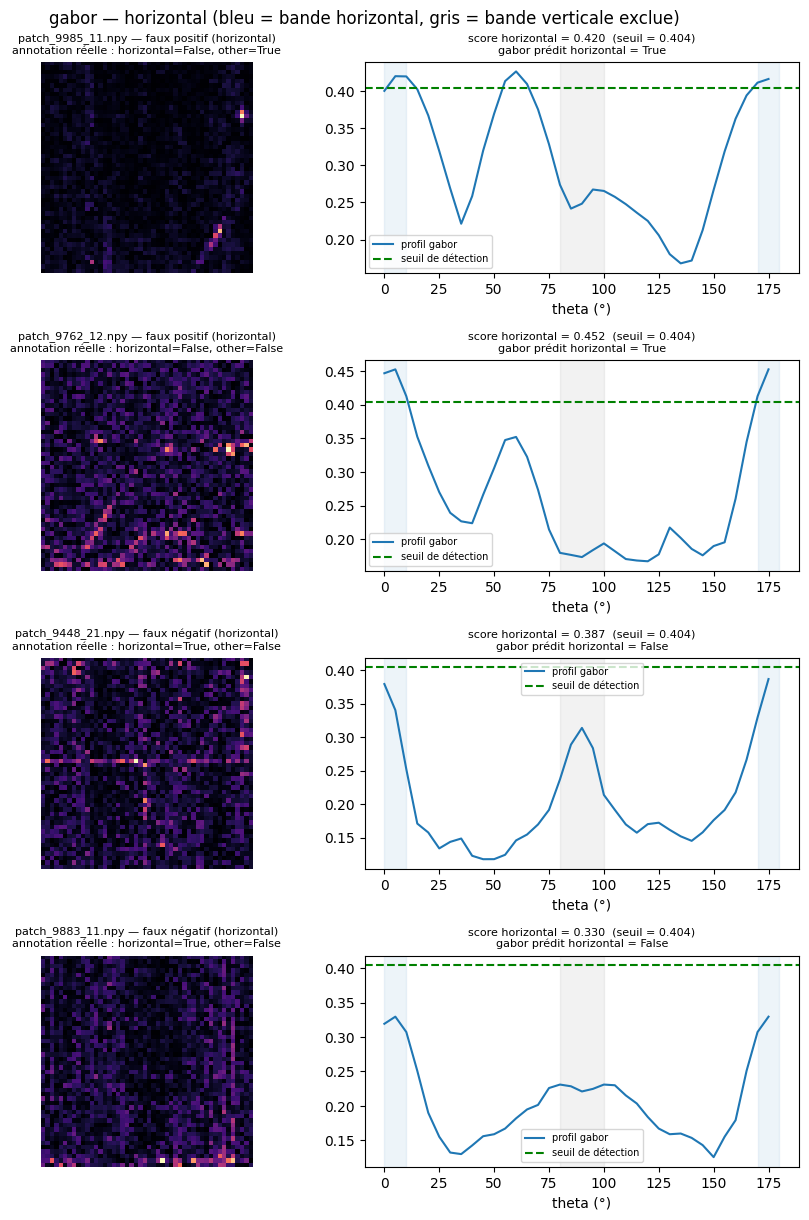

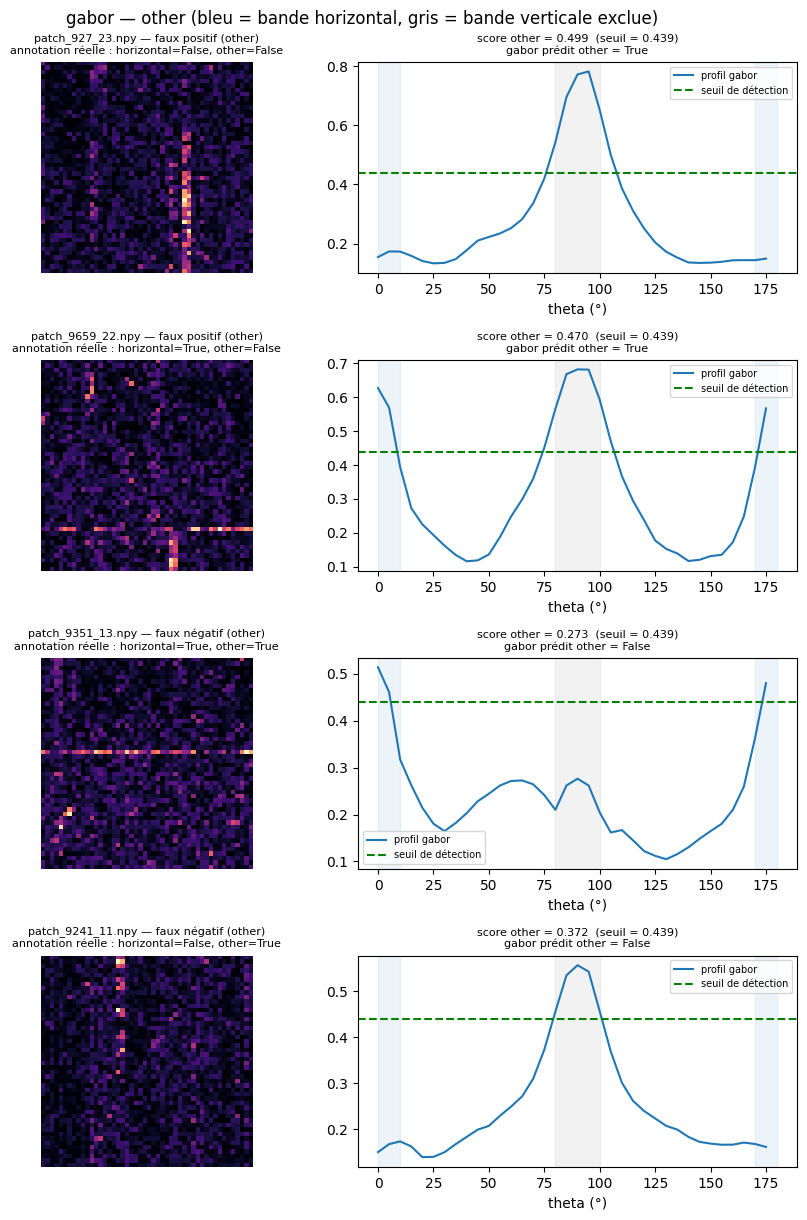

In [15]:
N_EXAMPLES = 2  # nombre de faux positifs / faux négatifs affichés par label

det_name = "gabor"
detector = detectors[det_name]
thresholds = THRESHOLDS[det_name]
scores = annotated_scores[det_name]

for j, (label, y) in enumerate([("horizontal", y_horizontal), ("other", y_other)]):
    s = scores[:, j]
    pred = s > thresholds[j]
    fp_idx = np.where(pred & ~y)[0][:N_EXAMPLES]
    fn_idx = np.where(~pred & y)[0][:N_EXAMPLES]
    examples = [(i, "faux positif") for i in fp_idx] + [(i, "faux négatif") for i in fn_idx]
    if not examples:
        continue

    fig, axes = plt.subplots(len(examples), 2, figsize=(9, 3.1 * len(examples)), squeeze=False)
    for row, (i, kind) in enumerate(examples):
        fname = annotated_files[i]
        a = annotations[fname]
        e = annotated_residuals[i]
        prof = detector(e)

        axes[row, 0].imshow(e, origin="lower", cmap="magma")
        axes[row, 0].set_title(
            f"{fname} — {kind} ({label})\n"
            f"annotation réelle : horizontal={a['horizontal']}, other={a['other']}",
            fontsize=8,
        )
        axes[row, 0].axis("off")

        axes[row, 1].plot(ANGLES, prof, label="profil gabor")
        axes[row, 1].axhline(thresholds[j], color="green", linestyle="--", label="seuil de détection")
        axes[row, 1].axvspan(0, H_TOL, color="tab:blue", alpha=0.08)
        axes[row, 1].axvspan(180 - H_TOL, 180, color="tab:blue", alpha=0.08)
        axes[row, 1].axvspan(90 - V_TOL, 90 + V_TOL, color="gray", alpha=0.10)
        axes[row, 1].set_xlabel("theta (°)")
        axes[row, 1].set_title(
            f"score {label} = {s[i]:.3f}  (seuil = {thresholds[j]:.3f})\n"
            f"gabor prédit {label} = {bool(pred[i])}",
            fontsize=8,
        )
        axes[row, 1].legend(fontsize=7)
    fig.suptitle(f"gabor — {label} (bleu = bande horizontal, gris = bande verticale exclue)")
    plt.tight_layout()
    plt.show()


dispersion du fond (std) : moyenne=0.0340, écart-type=0.0198, coefficient de variation=0.58
AUC score brut (pic)        : 0.831
AUC score normalisé (z-score): 0.524


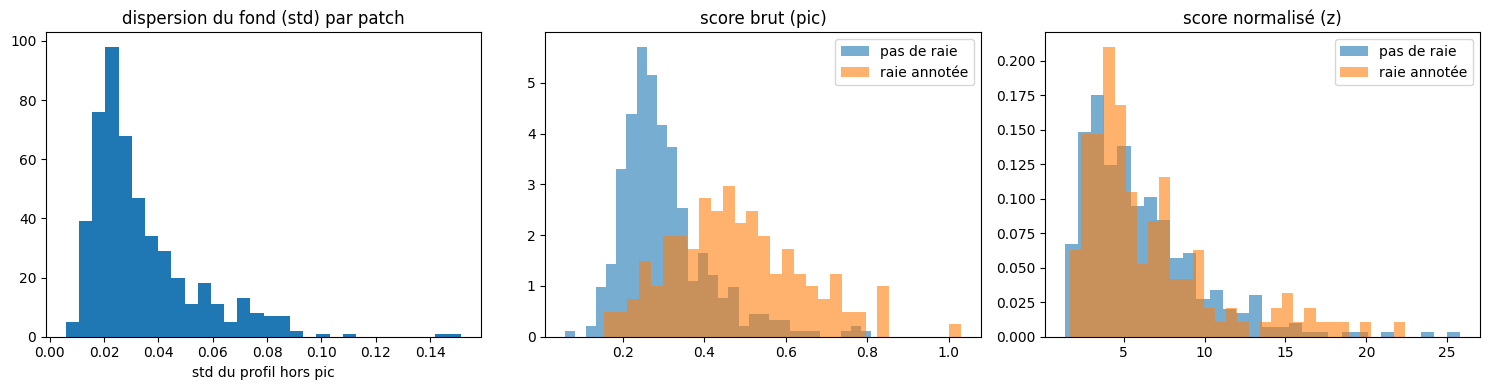

In [16]:
# Le fond du profil varie-t-il assez d'un patch à l'autre pour justifier de
# normaliser le pic par le bruit local (idée type CFAR), plutôt que d'utiliser
# un score brut ? On calcule, pour chaque patch, le pic du profil Gabor et la
# moyenne/écart-type du "fond" (profil hors d'une fenêtre de +-15° autour du
# pic), puis on compare le pouvoir séparateur (AUC) du score brut et du score
# normalisé z = (pic - fond) / std(fond) pour détecter "il y a une raie"
# (horizontal ou other, toutes orientations confondues).

has_line = y_horizontal | y_other
GUARD = 15.0  # demi-largeur (°) de la fenêtre exclue du fond autour du pic


def peak_and_background(profile: np.ndarray, angles: np.ndarray = ANGLES, guard: float = GUARD):
    i_peak = np.argmax(profile)
    dist = np.abs(angles - angles[i_peak])
    dist = np.minimum(dist, 180 - dist)  # distance circulaire (periode 180°)
    background = profile[dist > guard]
    return profile[i_peak], background.mean(), background.std()


peaks, bg_means, bg_stds = [], [], []
for e in annotated_residuals:
    p, m, s = peak_and_background(gabor_profile(e))
    peaks.append(p)
    bg_means.append(m)
    bg_stds.append(s)
peaks, bg_means, bg_stds = np.array(peaks), np.array(bg_means), np.array(bg_stds)
z_scores = (peaks - bg_means) / bg_stds

print(f"dispersion du fond (std) : moyenne={bg_stds.mean():.4f}, écart-type={bg_stds.std():.4f}, "
      f"coefficient de variation={bg_stds.std() / bg_stds.mean():.2f}")
print(f"AUC score brut (pic)        : {roc_auc(has_line, peaks):.3f}")
print(f"AUC score normalisé (z-score): {roc_auc(has_line, z_scores):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(bg_stds, bins=30)
axes[0].set_title("dispersion du fond (std) par patch")
axes[0].set_xlabel("std du profil hors pic")

for ax, values, title in [
    (axes[1], peaks, "score brut (pic)"),
    (axes[2], z_scores, "score normalisé (z)"),
]:
    ax.hist(values[~has_line], bins=30, alpha=0.6, density=True, label="pas de raie")
    ax.hist(values[has_line], bins=30, alpha=0.6, density=True, label="raie annotée")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()


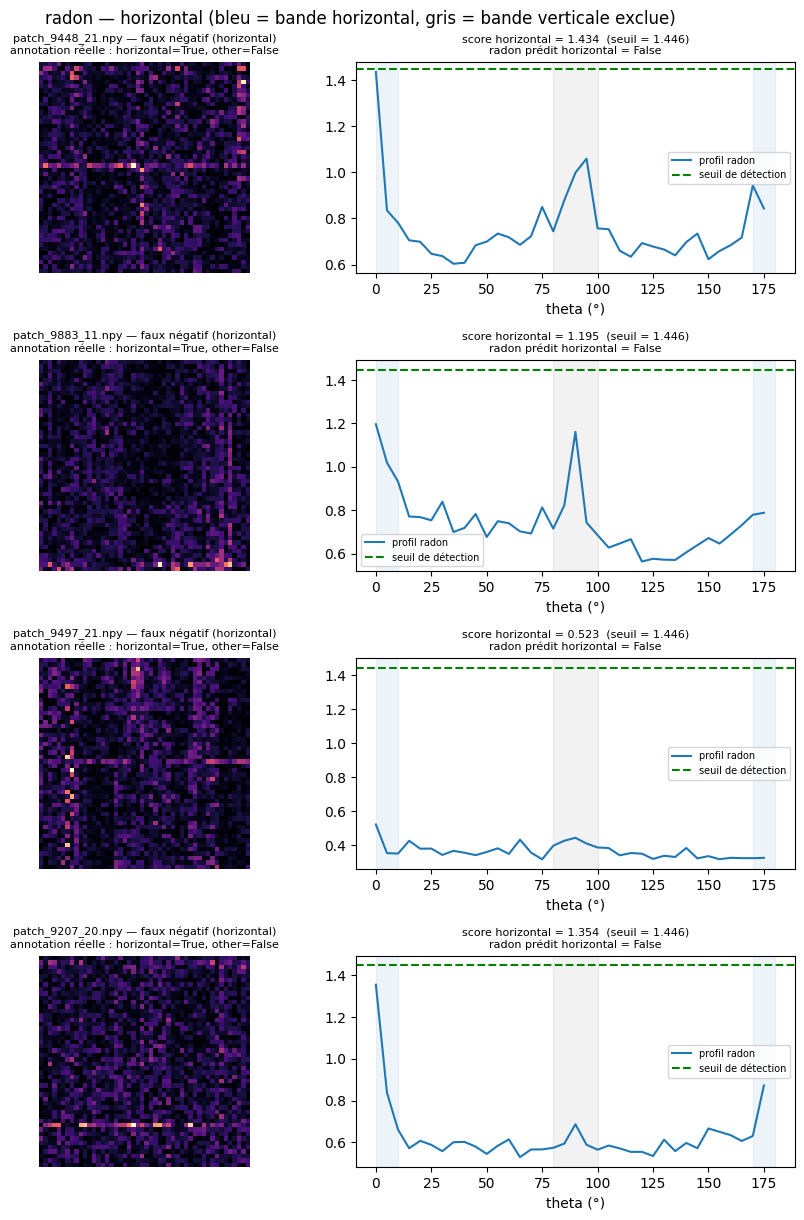

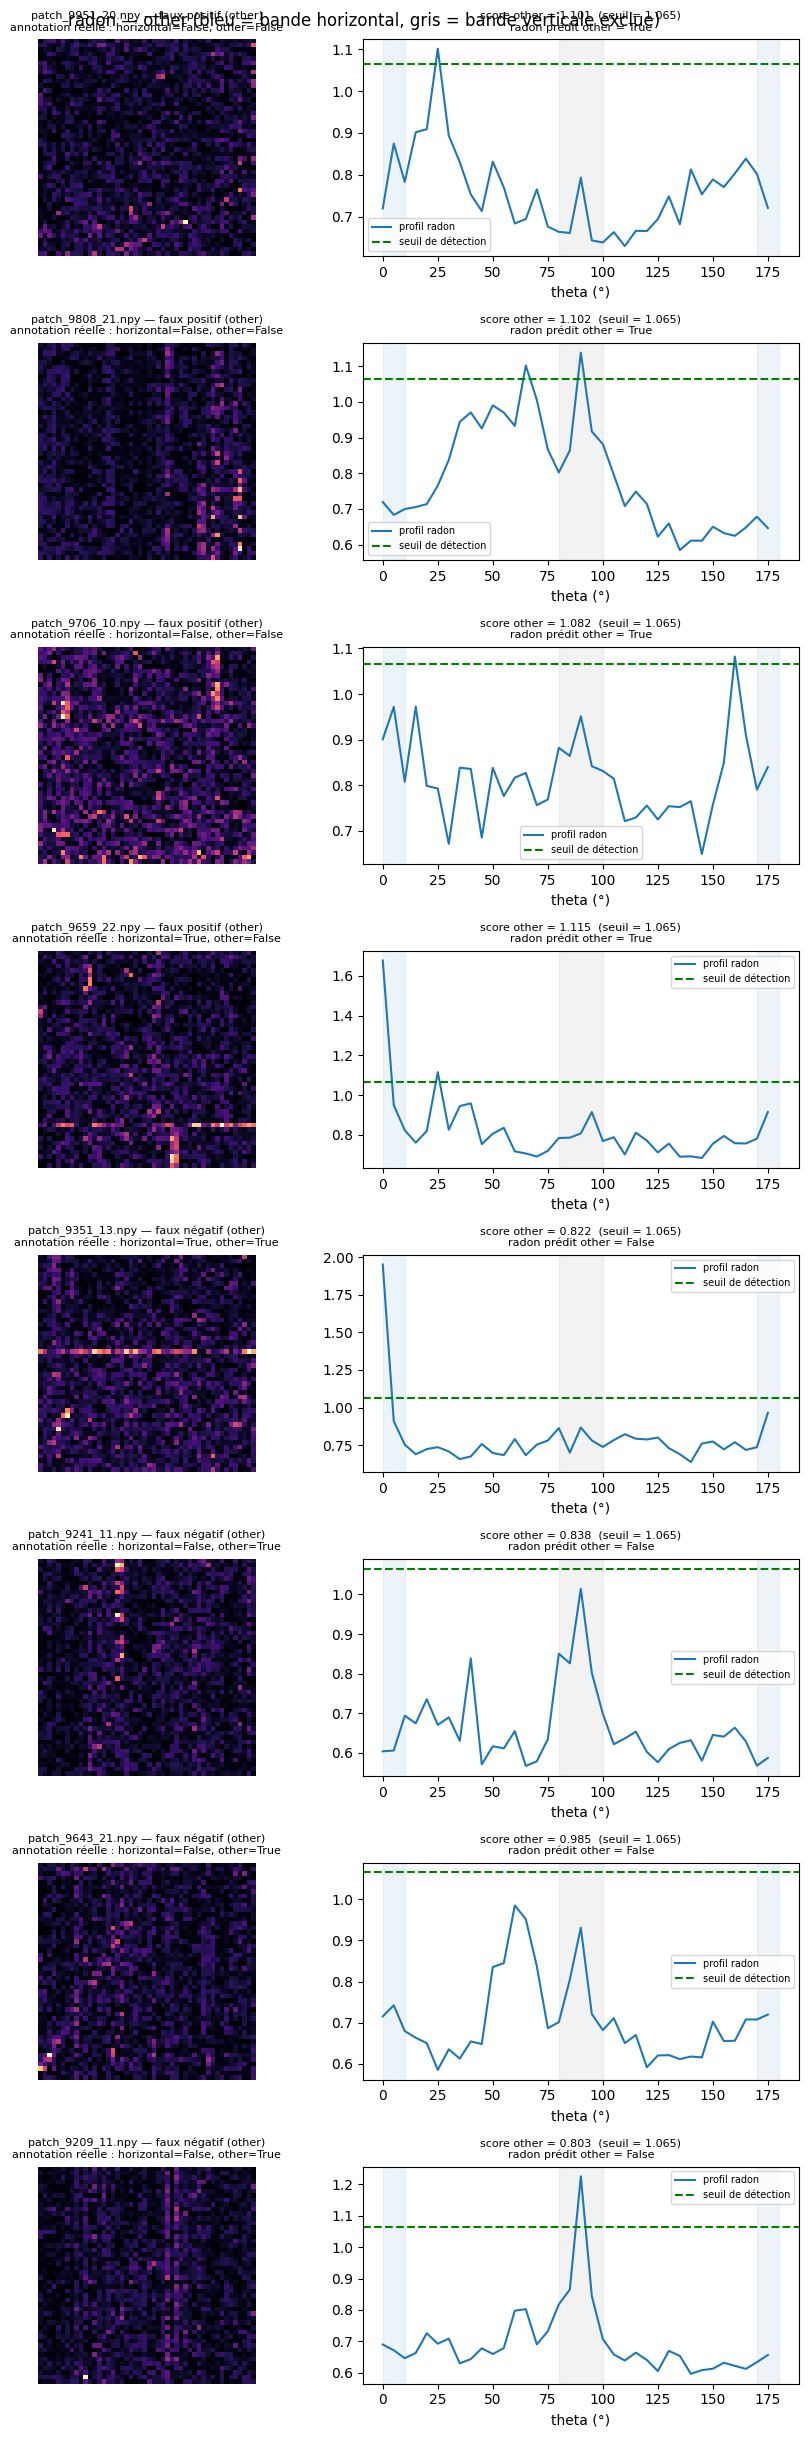

In [17]:
N_EXAMPLES = 4  # nombre de faux positifs / faux négatifs affichés par label (~15 au total)

det_name = "radon"
detector = detectors[det_name]
thresholds = THRESHOLDS[det_name]
scores = annotated_scores[det_name]

for j, (label, y) in enumerate([("horizontal", y_horizontal), ("other", y_other)]):
    s = scores[:, j]
    pred = s > thresholds[j]
    fp_idx = np.where(pred & ~y)[0][:N_EXAMPLES]
    fn_idx = np.where(~pred & y)[0][:N_EXAMPLES]
    examples = [(i, "faux positif") for i in fp_idx] + [(i, "faux négatif") for i in fn_idx]
    if not examples:
        continue

    fig, axes = plt.subplots(len(examples), 2, figsize=(9, 3.1 * len(examples)), squeeze=False)
    for row, (i, kind) in enumerate(examples):
        fname = annotated_files[i]
        a = annotations[fname]
        e = annotated_residuals[i]
        prof = detector(e)

        axes[row, 0].imshow(e, origin="lower", cmap="magma")
        axes[row, 0].set_title(
            f"{fname} — {kind} ({label})\n"
            f"annotation réelle : horizontal={a['horizontal']}, other={a['other']}",
            fontsize=8,
        )
        axes[row, 0].axis("off")

        axes[row, 1].plot(ANGLES, prof, label=f"profil {det_name}")
        axes[row, 1].axhline(thresholds[j], color="green", linestyle="--", label="seuil de détection")
        axes[row, 1].axvspan(0, H_TOL, color="tab:blue", alpha=0.08)
        axes[row, 1].axvspan(180 - H_TOL, 180, color="tab:blue", alpha=0.08)
        axes[row, 1].axvspan(90 - V_TOL, 90 + V_TOL, color="gray", alpha=0.10)
        axes[row, 1].set_xlabel("theta (°)")
        axes[row, 1].set_title(
            f"score {label} = {s[i]:.3f}  (seuil = {thresholds[j]:.3f})\n"
            f"{det_name} prédit {label} = {bool(pred[i])}",
            fontsize=8,
        )
        axes[row, 1].legend(fontsize=7)
    fig.suptitle(f"{det_name} — {label} (bleu = bande horizontal, gris = bande verticale exclue)")
    plt.tight_layout()
    plt.show()
